# Scenario 1 — US / Russia full-scale nuclear war

End-to-end fertilizer-trade RAS run for a scenario based on the ALLFED preprint:

- **24 %** of US industrial infrastructure destroyed in the OPEN-RISOP scenario.
- Estimated to cause a **60 % decline** in US industrial production.
- Same assumption applied to **Russia (-60 %)**.
- US + Russia together are **17 %** of world industrial GDP.
- To match an overall **25 %** global industrial output decline, the remaining countries absorb an **18 %** production cut.

So in this notebook:

| Group | Surviving production fraction |
|---|---|
| United States of America | 0.40  (−60 %) |
| Russian Federation | 0.40  (−60 %) |
| Every other country | 0.82  (−18 %) |

The logic follows `scripts/real_data_nitrogen.ipynb`; the only difference is how the `SHOCK` dict is built. All heavy lifting lives in `src/`.

> For **N, P and K in one run**, use `scenario1_us_russia_nuclear_all_nutrients.ipynb`.

> Before running: download the FAOSTAT bulk extracts as described in `data/README.md`.

In [ ]:
import sys, pathlib

sys.path.append(str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd

from src.preprocessing import load_nutrient, apply_shock_reported
from src.model import FertilizerRAS
from src.postprocessing import (
    build_comparison, most_affected, least_affected,
    global_summary, sanity_checks, save_result,
)
from src.utils import plot_comparison_dashboard

pd.set_option('display.float_format', '{:,.0f}'.format)

## 1. Configuration

Scenario parameters are grouped at the top so you can quickly derive other variants (different surviving fractions, different countries) without touching the rest of the notebook.

In [ ]:
NUTRIENT = 'N'           # one of 'N', 'P', 'K'
YEARS = list(range(2014, 2019))
MIN_THRESHOLD = 1_000    # tonnes; drop countries with tiny P and C

INPUTS_CSV = '../data/Inputs_FertilizersNutrient_E_All_Data/Inputs_FertilizersNutrient_E_All_Data_NOFLAG.csv'
TRADE_CSV  = '../data/Fertilizers_DetailedTradeMatrix_E_All_Data/Fertilizers_DetailedTradeMatrix_E_All_Data_NOFLAG.csv'

# Scenario 1 — US / Russia full-scale nuclear war
HEAVY_HIT = {
    'United States of America': 0.40,  # -60%
    'Russian Federation':       0.40,  # -60%
}
REST_OF_WORLD_FRACTION = 0.82           # -18% for every other country
SCENARIO_TAG = 'scenario1_us_ru_nuclear'

## 2. Load FAOSTAT data

In [ ]:
data = load_nutrient(INPUTS_CSV, TRADE_CSV, nutrient=NUTRIENT, years=YEARS, min_threshold=MIN_THRESHOLD)

P, C, T0 = data['P'], data['C'], data['T0']
print(f'Countries: {len(data["countries"])}')
print(f'Total production: {P.sum():,.0f} t')
print(f'Total demand:     {C.sum():,.0f} t')
print(f'Total trade (T0): {T0.values.sum():,.0f} t')

display(P.nlargest(10).to_frame('Production (t)'))
display(C.nlargest(10).to_frame('Demand (t)'))

Countries: 191
Total production: 535,894,909 t
Total demand:     490,413,548 t
Total trade (T0): 49,479,829 t


,Production (t)
Area,
World,"119,063,036"
Asia,"72,169,458"
Eastern Asia,"37,355,454"
China,"36,365,419"
"China, mainland","36,265,227"
Europe,"23,403,656"
Southern Asia,"18,224,500"
Americas,"17,482,104"
Eastern Europe,"15,311,967"


,Demand (t)
Area,
World,"108,213,683"
Asia,"64,511,384"
Eastern Asia,"30,869,045"
China,"30,122,251"
"China, mainland","29,970,308"
Americas,"23,120,654"
Southern Asia,"22,653,717"
India,"17,128,700"
Europe,"14,833,560"


## 3. Build scenario shock vector

Every country in the filtered set gets a surviving fraction. Start with `REST_OF_WORLD_FRACTION` (−18 %) for all, then overwrite the heavily hit countries (−60 %). We also print a sanity check showing that the global production decline lands near the −25 % target from the preprint.

In [ ]:
SHOCK = {country: REST_OF_WORLD_FRACTION for country in P.index}
for country, frac in HEAVY_HIT.items():
    if country in SHOCK:
        SHOCK[country] = frac
    else:
        print(f'WARNING: {country!r} not in the filtered FAOSTAT index — check the exact FAO name.')

P_shocked, report = apply_shock_reported(P, SHOCK)

if report.unmatched:
    print('Unmatched country names in SHOCK dict:', report.unmatched)

global_prod_before = float(P.sum())
global_prod_after  = float(P_shocked.sum())
global_decline_pct = (1 - global_prod_after / global_prod_before) * 100

print(f'Global production before: {global_prod_before:,.0f} t')
print(f'Global production after : {global_prod_after:,.0f} t')
print(f'Global decline          : {global_decline_pct:.2f} %   (target: 25 %)')

us_ru_share_before = (
    P.get('United States of America', 0) + P.get('Russian Federation', 0)
) / max(global_prod_before, 1e-12) * 100
print(f'US+Russia share of baseline fertilizer production: {us_ru_share_before:.1f} %')

display(report.as_dataframe().head(8))
print(f'... ({len(report.applied)} countries shocked in total)')

Global production before: 535,894,909 t
Global production after : 431,051,330 t
Global decline          : 19.56 %   (target: 25 %)
US+Russia share of baseline fertilizer production: 3.7 %


,country,P_before,P_after,surviving_fraction
0,Afghanistan,"14,416","11,821",1
1,Africa,"5,510,558","4,518,658",1
2,Albania,0,0,1
3,Algeria,"869,100","712,662",1
4,Americas,"17,482,104","14,335,325",1
5,Angola,0,0,1
6,Argentina,"499,754","409,799",1
7,Armenia,0,0,1


... (191 countries shocked in total)


## 4. Run baseline + shocked through the RAS pipeline

In [ ]:
baseline = FertilizerRAS(P,         C, T0).run(verbose=True)
shocked  = FertilizerRAS(P_shocked, C, T0).run(verbose=True)

display(sanity_checks(baseline))
display(sanity_checks(shocked))

RAS converged in 98 iterations (max_err=8.57e-07)
RAS converged in 166 iterations (max_err=9.45e-07)


,max_row_error,max_col_error,sum_X,sum_F,sum_K_plus_X,F_eq_K_plus_X,rows_ok,cols_ok
0,0,0,"54,229,795","490,413,548","490,413,548",True,True,True


,max_row_error,max_col_error,sum_X,sum_F,sum_K_plus_X,F_eq_K_plus_X,rows_ok,cols_ok
0,0,0,"38,166,427","431,051,330","431,051,330",True,True,True


## 5. Compare and report

In [ ]:
comparison = build_comparison(baseline, shocked)

print('Global summary:')
display(global_summary(baseline, shocked))

print('\nMost affected (largest coverage drop):')
display(most_affected(comparison, n=15))

print('\nLeast affected / improved:')
display(least_affected(comparison, n=10))

Global summary:


,baseline,shocked,change
Total production,"535,894,909","431,051,330","-104,843,579"
Total demand,"490,413,548","490,413,548",0
Total trade (sum X),"54,229,795","38,166,427","-16,063,368"
Total availability (sum F),"490,413,548","431,051,330","-59,362,218"
Global coverage %,100,88,-12



Most affected (largest coverage drop):


,P_baseline,P_shocked,Demand,F_baseline,F_shocked,Cover_base_%,Cover_shock_%,Change_pp,Avail_vs_baseline_%,Avail_reduction_%
Area,,,,,,,,,,
Albania,0,0,"34,873","34,873","13,647",100,39,-61,39,61
Angola,0,0,"24,449","24,449","9,568",100,39,-61,39,61
Armenia,0,0,"75,624","75,624","29,595",100,39,-61,39,61
Austria,0,0,"119,066","119,066","46,595",100,39,-61,39,61
Azerbaijan,0,0,"80,979","80,979","31,690",100,39,-61,39,61
Bahamas,0,0,"1,223","1,223",479,100,39,-61,39,61
Belize,0,0,"16,384","16,384","6,412",100,39,-61,39,61
Benin,0,0,"15,449","15,449","6,046",100,39,-61,39,61
Botswana,0,0,"12,642","12,642","4,947",100,39,-61,39,61



Least affected / improved:


,P_baseline,P_shocked,Demand,F_baseline,F_shocked,Cover_base_%,Cover_shock_%,Change_pp,Avail_vs_baseline_%,Avail_reduction_%
Area,,,,,,,,,,
Africa,"5,510,558","4,518,658","3,868,819","3,868,819","3,868,819",100,100,0,100,0
Algeria,"869,100","712,662","72,300","72,300","72,300",100,100,0,100,0
Bahrain,"335,525","275,131","1,255","1,255","1,255",100,100,0,100,0
Belarus,"854,078","700,344","412,019","412,019","412,019",100,100,0,100,0
Belgium,"833,324","683,326","163,761","163,761","163,761",100,100,0,100,0
Bulgaria,"468,788","384,406","336,500","336,500","336,500",100,100,0,100,0
Canada,"3,876,632","3,178,838","2,565,000","2,565,000","2,565,000",100,100,0,100,0
Caribbean,"674,128","552,785","151,333","151,333","151,333",100,100,0,100,0
Central Asia,"1,534,827","1,258,558","1,243,882","1,243,882","1,243,882",100,100,0,100,0


## 6. Mass-balance sanity checks

Same checks as `toy_example.ipynb` (`postprocessing.sanity_checks`). Expect `rows_ok` and `cols_ok` True.

In [ ]:
print('Baseline:')
display(sanity_checks(baseline))
print('Shocked:')
display(sanity_checks(shocked))

## 7. Plots

C:\Users\smrko\AppData\Local\Temp\ipykernel_23316\1083522252.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


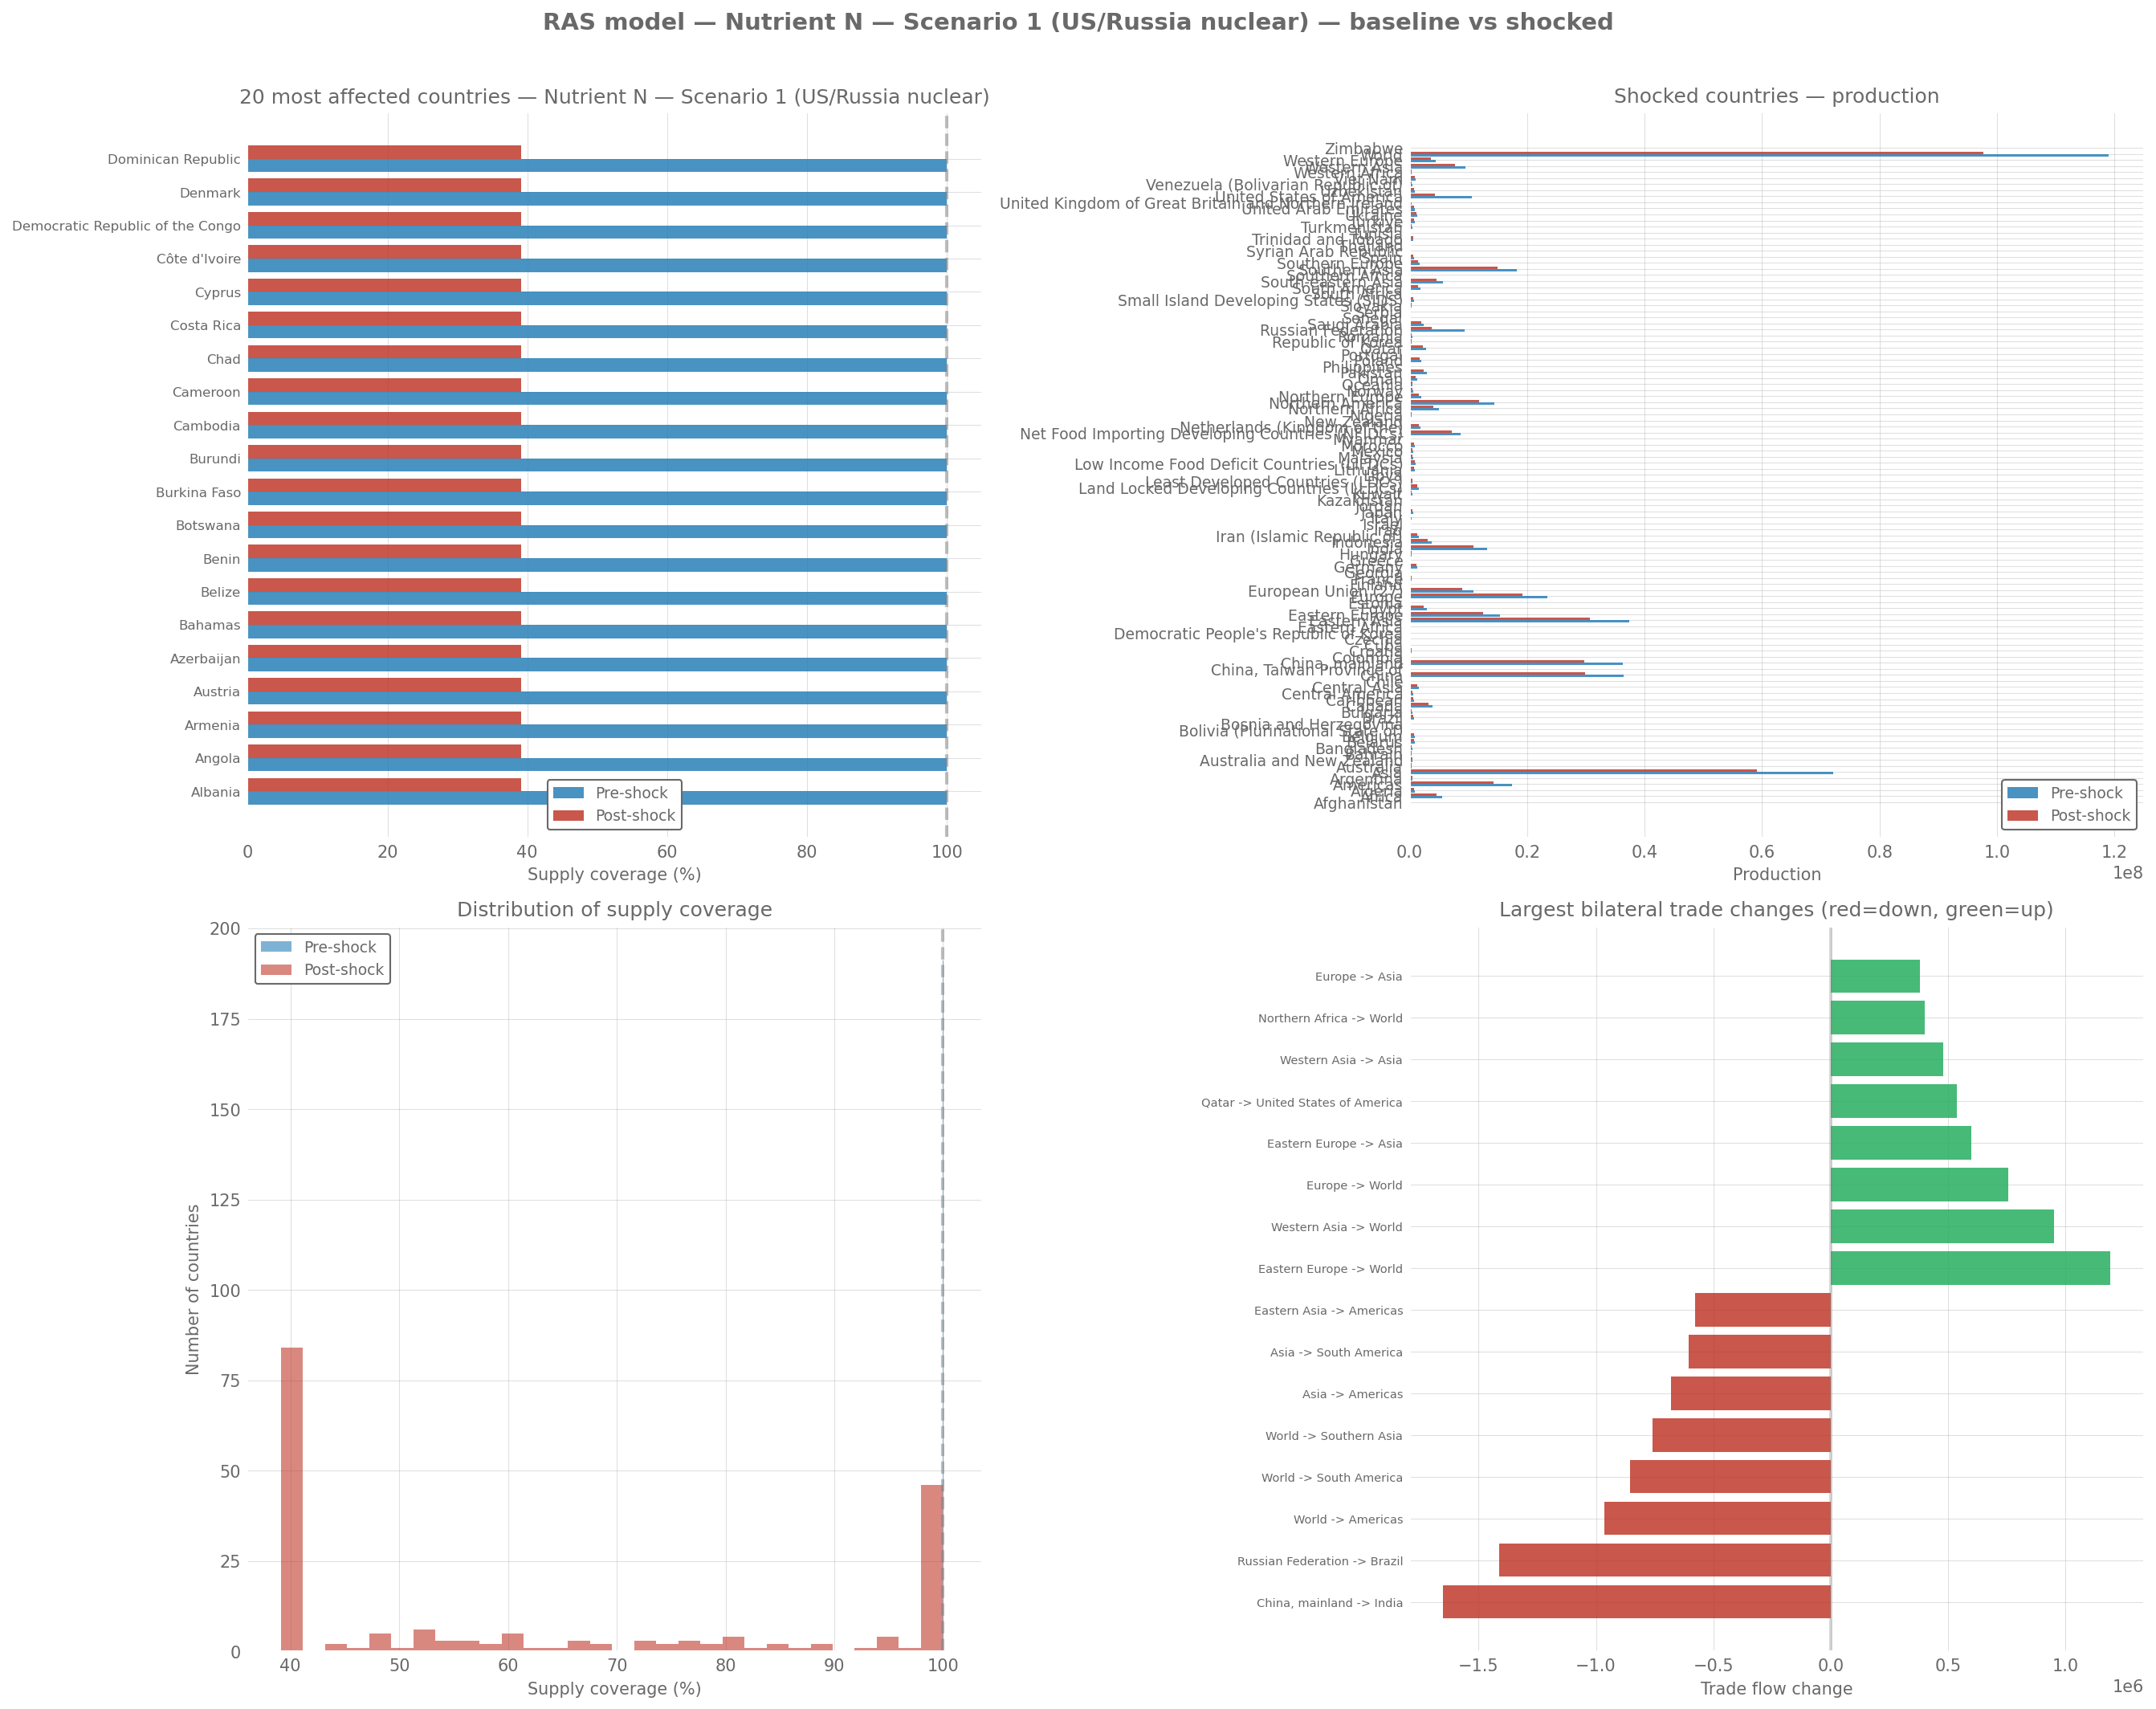

In [ ]:
fig = plot_comparison_dashboard(
    baseline, shocked, comparison,
    nutrient_name=f'Nutrient {NUTRIENT} — Scenario 1 (US/Russia nuclear)',
)
fig.show()

## 8. Save results to `results/`

In [ ]:
save_result(baseline, '../results', tag=f'{NUTRIENT}_{SCENARIO_TAG}_baseline')
save_result(shocked,  '../results', tag=f'{NUTRIENT}_{SCENARIO_TAG}_shocked')

{'X': WindowsPath('../results/X_N_scenario1_us_ru_nuclear_shocked.csv'),
 'summary': WindowsPath('../results/summary_N_scenario1_us_ru_nuclear_shocked.csv')}